In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# ============================================================================
# MODEL PARAMETERS
# ============================================================================

T1 = 23.2 # Mean temperature in the absence of seasonality (°C)
T2 = 0.07 # Amplitude of seasonal variability in temperature (Dimensionless)
omega1 = 0.67 # (Angular) frequency of seasonal oscillations in temperature (Months)^-1
phi1 = 1.53 # Phase lag of temperature variability (Dimensionless) 
R1 = 23.2 # Mean monthly rainfall in the absence of seasonality (mm)
R2 = 0.98 # Amplitude of seasonal variability in rainfall (Dimensionless)
omega2 = 0.65 # (Angular) frequency of seasonal oscillations in rainfall (Months)^-1
phi2 = 1.99 # Phase lag of rainfall variability (Dimensionless) 
T_prime = 19.9 # Temperature threshold for biting to occur, below this temperature the mosquito is inactive (°C)
B_E = 200 # Number of eggs laid per adult per oviposition (Dimensionless) 
p_ME = 0.9 # Maximum daily survival probability of eggs (Dimensionless) 
p_ML = 0.25 # Maximum daily survival probability of larvae (Dimensionless) 
p_MP = 0.75 # Maximum daily survival probability of pupae (Dimensionless) 
tau_E = 1 # Duration of egg development stage (Days)
tau_P = 1 # Duration of pupae development stage (Days)
c1 = 0.00554 # Sum of heat in degree-days required to complete the larval cycle, how much the development rate accelerates per °C (°C days)^-1
c2 = -0.06737 # Development rate at 0°C (Days)^-1 - Development stops below a threshold temperature T_t = -c2/c1
D1 = 36.5 # How quickly the biting rate increases per °C above the T' threshold (°C days)
A = -0.03 # Negative to ensure mortality drops to zero below a minimum and maximum temperature (°C^2 days)^-1
B = 1.31 # Positive to ensure the peak survivability (lowest mortality) is at a positive temperature (°C days)^-1
C = -4.4 # Baseline mortality at T=0°C, negative to ensure mortality falls to 0 at a positive temperature # (Days)^-1
DD = 105 # Degree days for development of parasit - Sum of heat in degree-days required for completing a sporogonic cycle (°C days)
Tmin = 14.5 # Minimal temperature that allows for mosquito survivability, below this temperature the population cannot survive (°C)
R_L = 50 # Rainfall limit beyond which breeding sites get flushed out and no immature stages survive (mm)

In [3]:
def Temp(t):
    return T1*(1+T2*np.cos(omega1*t - phi1))

def Rain(t):
    return R1*(1+R2*np.cos(omega2*t - phi2))

In [4]:
# ============================================================================
# MOSQUITO LIFE CYCLE FUNCTIONS
# ============================================================================

### Duration of larval development stage
def tau_L(Temp):
    denom = c1 * Temp + c2
    # Avoiding division by zero or negative denominator
    result = np.where(denom <= 0, np.inf, 1 / denom)
    return result

### Daily survival probability
def p_T(Temp):#, Umid):
    denom = A * Temp**2 + B * Temp + C
    # Ensuring the denominator is positive
    p_T_temp = np.where(denom <= 0, 0, np.exp(-1/denom))
    
    # if Umid < 50:
    #     p_U = 0.0
    # elif Umid < 60:
    #     p_U = (Umid - 50) / 10
    # else:
    #     p_U = 1.0
    
    return p_T_temp #* p_U
### The paper mentions that p(T) as defined above is true only at favourable humidities for mosquito development,
### and that survival drops off rapidly at relative humidities below 50-60%. As the paper does not give data on humidity,
### we will assume that this is always valid for now

### Daily survival probability of larvae dependent on temperature (Development rate of eggs and pupae is relatively independent of temperature)
def p_LT(Temp):
    exponent = c1 * Temp + c2
    p_LT_temp = np.where(exponent <= 0, 0, np.exp(-exponent))
    return p_LT_temp

### Daily survival probability of larvae dependent on rainfall
def p_LR(Rain):
    p_LR_rainfall = np.where((Rain < 0) | (Rain > R_L), 0, (4 * p_ML / R_L**2) * Rain * (R_L - Rain))
    return p_LR_rainfall

# ### Daily survival probability of larvae
def p_L_combined(Temp, Rain):
    return p_LT(Temp) * p_LR(Rain)

### Daily survival probability of eggs dependent on rainfall
def p_ER(Rain):
    p_ER_rainfall = np.where((Rain < 0) | (Rain > R_L), 0, (4 * p_ME / R_L**2) * Rain * (R_L - Rain))
    return p_ER_rainfall

### Daily survival probability of pupae dependent on rainfall
def p_PR(Rain):
    p_PR_rainfall = np.where((Rain < 0) | (Rain > R_L), 0, (4 * p_MP / R_L**2) * Rain * (R_L - Rain))
    return p_PR_rainfall

### Duration of the sporogonic cycle (Days)
def tau_M(Temp):
    tau_M = np.where(Temp <= Tmin, np.inf, DD / (Temp - Tmin))
    return tau_M
    
### Probability of a mosquito surviving the duration of the sporogonic cycle
def l_tau_M(Temp):
    p_T_val = p_T(Temp)#, Umid)
    tau_M_val = tau_M(Temp)
    result = np.where((tau_M_val == np.inf) | (p_T_val <= 0), 0, p_T_val**tau_M_val)
    return result

### Mortality hazard (deaths per mosquito per day) - Adult mosquito per capita death rate (Days)^-1
def mu(Temp):# , Umid):
    p_T_val = p_T(Temp)
    mu_val = np.where(p_T_val <= 0, np.inf, -np.log(p_T_val))
    return mu_val

### Biting rate (Days)^-1
def a(Temp): 
    a_val = np.maximum(0, (Temp - T_prime) / D1)
    return a_val
### Currently, a(T) does not take into consideration heat death above a certain temperature threshold, 
### nor an optimal temperature wherebiting peaks. This may be reconsidered later 

### Adult mosquito birth rate (Days)^-1
def b(Temp, Rain):
    tau_L_val = tau_L(Temp)
    numerator = B_E * p_ER(Rain) * p_LR(Rain) * p_LT(Temp) * p_PR(Rain)
    denominator = tau_E + tau_L_val + tau_P
    result = np.where((denominator <= 0) | (tau_L_val == np.inf), 0, numerator / denominator)
    return result

print('Functions loaded successfully!')

Functions loaded successfully!


In [5]:
# ============================================================================
# PLOTTING
# ============================================================================

# Create array of days
t = np.linspace(0, 366, 500)

# Calculate temperature and rainfall over time
temperature = np.array([Temp(day) for day in t])
rainfall = np.array([Rain(day) for day in t])

# Calculate derived quantities
tau_L_vals = np.array([tau_L(Temp(day)) for day in t])
p_T_vals = np.array([p_T(Temp(day)) for day in t])
p_LT_vals = np.array([p_LT(Temp(day)) for day in t])
p_LR_vals = np.array([p_LR(Rain(day)) for day in t])
p_ER_vals = np.array([p_ER(Rain(day)) for day in t])
p_PR_vals = np.array([p_PR(Rain(day)) for day in t])
tau_M_vals = np.array([tau_M(Temp(day)) for day in t])
l_tau_M_vals = np.array([l_tau_M(Temp(day)) for day in t])
mu_vals = np.array([mu(Temp(day)) for day in t])
a_vals = np.array([a(Temp(day)) for day in t])
b_vals = np.array([b(Temp(day), Rain(day)) for day in t])

# Replace infinite values with NaN for plotting
tau_L_vals = np.where(np.isinf(tau_L_vals), np.nan, tau_L_vals)
tau_M_vals = np.where(np.isinf(tau_M_vals), np.nan, tau_M_vals)
mu_vals = np.where(np.isinf(mu_vals), np.nan, mu_vals)

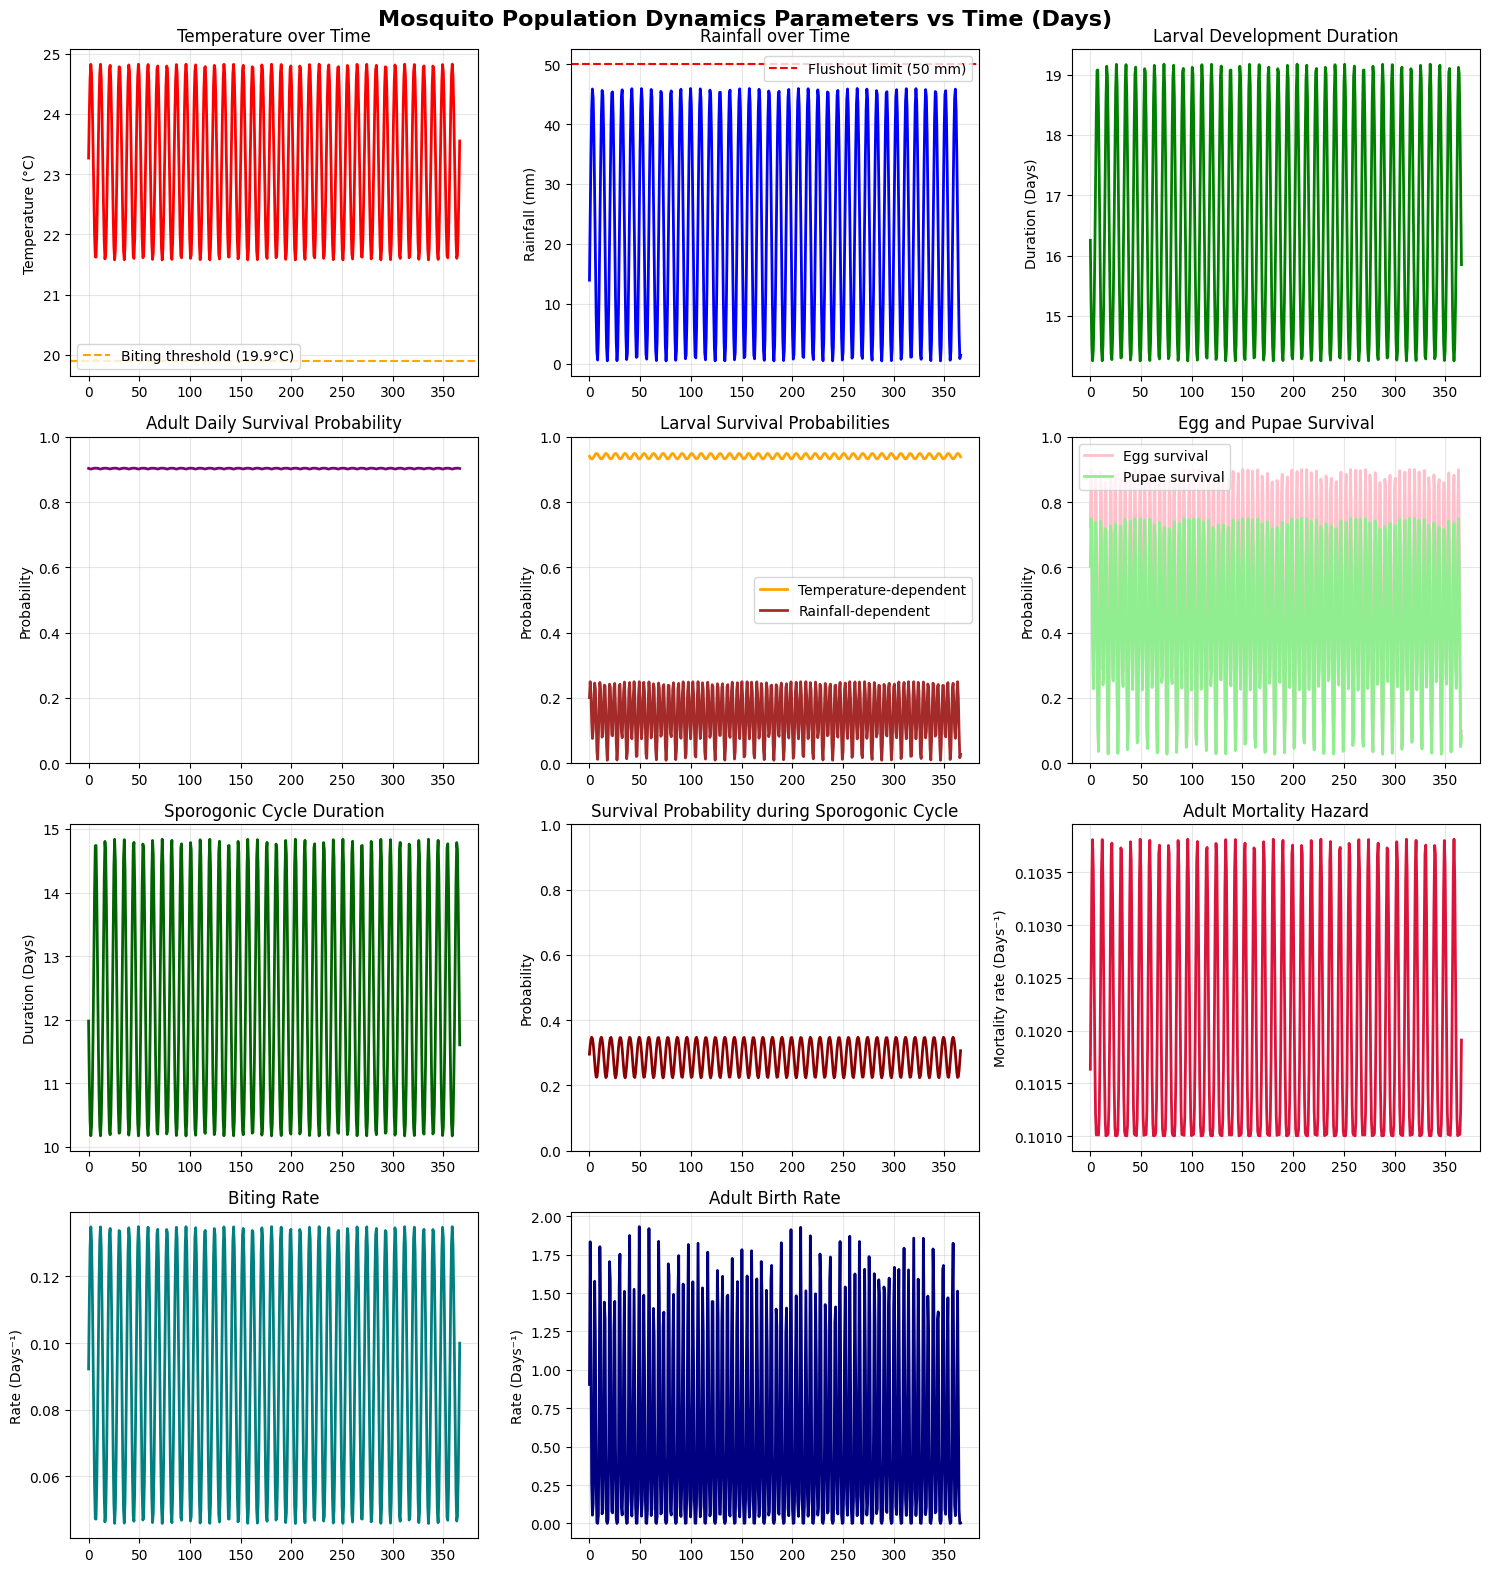

In [6]:
# ============================================================================
# MATPLOTLIB PLOTS
# ============================================================================

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
fig.suptitle('Mosquito Population Dynamics Parameters vs Time (Days)', fontsize=16, fontweight='bold')

# Row 1: Environmental variables
axes[0, 0].plot(t, temperature, 'r-', linewidth=2)
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].set_title('Temperature over Time')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(T_prime, color='orange', linestyle='--', label=f'Biting threshold ({T_prime}°C)')
axes[0, 0].legend()

axes[0, 1].plot(t, rainfall, 'b-', linewidth=2)
axes[0, 1].set_ylabel('Rainfall (mm)')
axes[0, 1].set_title('Rainfall over Time')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(R_L, color='red', linestyle='--', label=f'Flushout limit ({R_L} mm)')
axes[0, 1].legend()

axes[0, 2].plot(t, tau_L_vals, 'g-', linewidth=2)
axes[0, 2].set_ylabel('Duration (Days)')
axes[0, 2].set_title('Larval Development Duration')
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Survival probabilities
axes[1, 0].plot(t, p_T_vals, 'purple', linewidth=2)
axes[1, 0].set_ylabel('Probability')
axes[1, 0].set_title('Adult Daily Survival Probability')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

axes[1, 1].plot(t, p_LT_vals, 'orange', linewidth=2, label='Temperature-dependent')
axes[1, 1].plot(t, p_LR_vals, 'brown', linewidth=2, label='Rainfall-dependent')
axes[1, 1].set_ylabel('Probability')
axes[1, 1].set_title('Larval Survival Probabilities')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()
axes[1, 1].set_ylim([0, 1])

axes[1, 2].plot(t, p_ER_vals, 'pink', linewidth=2, label='Egg survival')
axes[1, 2].plot(t, p_PR_vals, 'lightgreen', linewidth=2, label='Pupae survival')
axes[1, 2].set_ylabel('Probability')
axes[1, 2].set_title('Egg and Pupae Survival')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()
axes[1, 2].set_ylim([0, 1])

# Row 3: Parasite and adult parameters
axes[2, 0].plot(t, tau_M_vals, 'darkgreen', linewidth=2)
axes[2, 0].set_ylabel('Duration (Days)')
axes[2, 0].set_title('Sporogonic Cycle Duration')
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(t, l_tau_M_vals, 'darkred', linewidth=2)
axes[2, 1].set_ylabel('Probability')
axes[2, 1].set_title('Survival Probability during Sporogonic Cycle')
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].set_ylim([0, 1])

axes[2, 2].plot(t, mu_vals, 'crimson', linewidth=2)
axes[2, 2].set_ylabel('Mortality rate (Days⁻¹)')
axes[2, 2].set_title('Adult Mortality Hazard')
axes[2, 2].grid(True, alpha=0.3)

# Row 4: Behavior rates
axes[3, 0].plot(t, a_vals, 'teal', linewidth=2)
axes[3, 0].set_ylabel('Rate (Days⁻¹)')
axes[3, 0].set_title('Biting Rate')
axes[3, 0].grid(True, alpha=0.3)

axes[3, 1].plot(t, b_vals, 'navy', linewidth=2)
axes[3, 1].set_ylabel('Rate (Days⁻¹)')
axes[3, 1].set_title('Adult Birth Rate')
axes[3, 1].grid(True, alpha=0.3)

# Hide the empty subplot
axes[3, 2].axis('off')

plt.tight_layout()
plt.show()

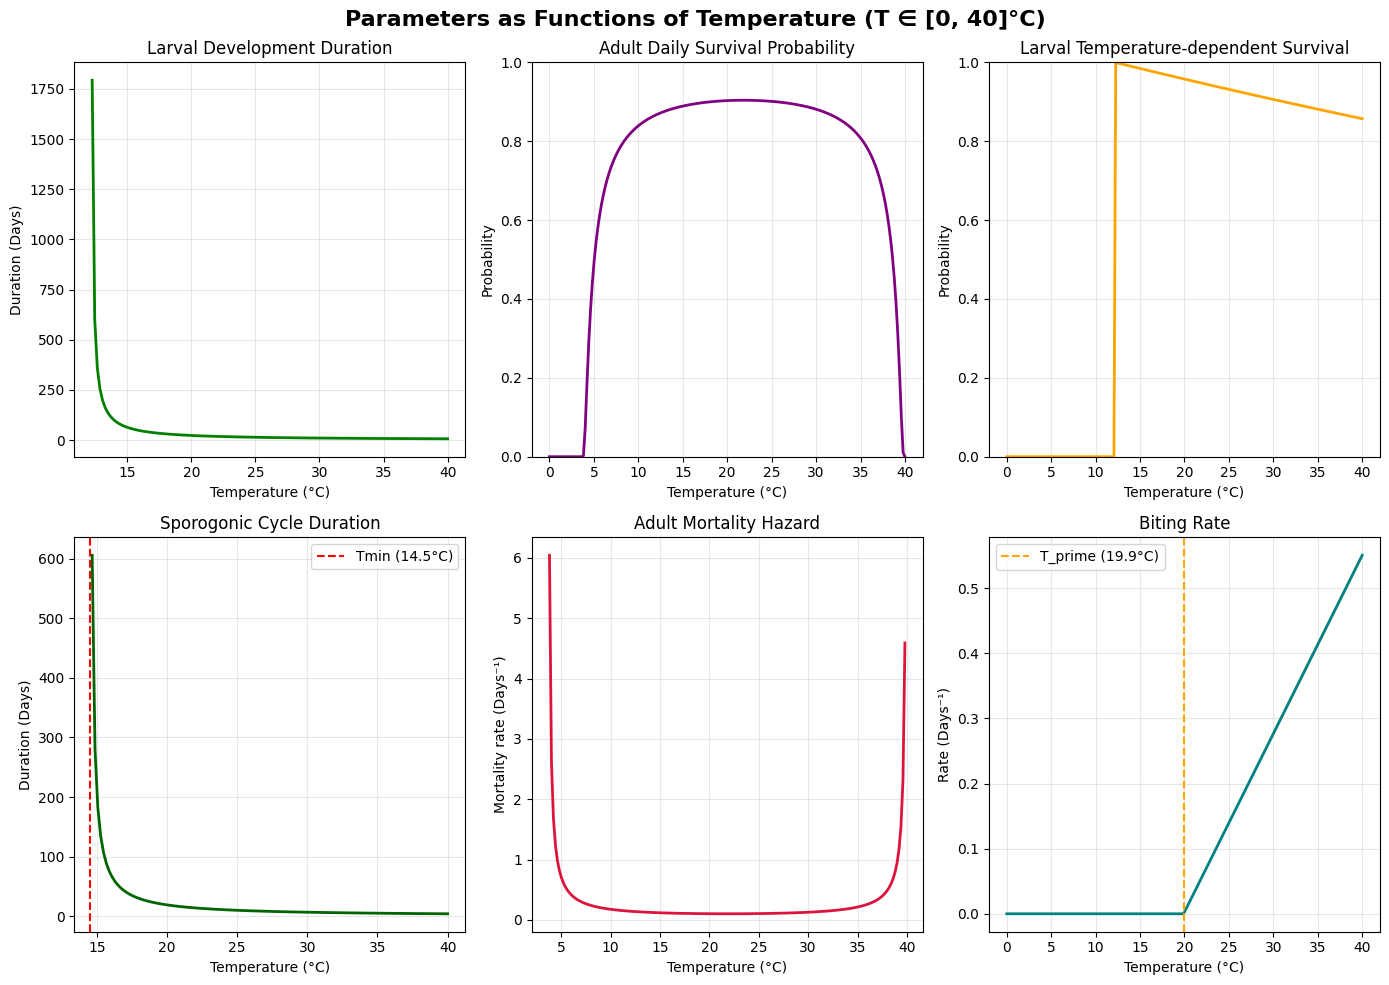

In [7]:
# ============================================================================
# FUNCTION OF TEMPERATURE PLOTS
# ============================================================================

temp_range = np.linspace(0, 40, 200)

fig2, axes2 = plt.subplots(2, 3, figsize=(14, 10))
fig2.suptitle('Parameters as Functions of Temperature (T ∈ [0, 40]°C)', fontsize=16, fontweight='bold')

# tau_L vs Temperature
tau_L_temp = np.array([tau_L(T) for T in temp_range])
axes2[0, 0].plot(temp_range, tau_L_temp, 'g-', linewidth=2)
axes2[0, 0].set_xlabel('Temperature (°C)')
axes2[0, 0].set_ylabel('Duration (Days)')
axes2[0, 0].set_title('Larval Development Duration')
axes2[0, 0].grid(True, alpha=0.3)

# p_T vs Temperature
p_T_temp = np.array([p_T(T) for T in temp_range])
axes2[0, 1].plot(temp_range, p_T_temp, 'purple', linewidth=2)
axes2[0, 1].set_xlabel('Temperature (°C)')
axes2[0, 1].set_ylabel('Probability')
axes2[0, 1].set_title('Adult Daily Survival Probability')
axes2[0, 1].grid(True, alpha=0.3)
axes2[0, 1].set_ylim([0, 1])

# p_LT vs Temperature
p_LT_temp = np.array([p_LT(T) for T in temp_range])
axes2[0, 2].plot(temp_range, p_LT_temp, 'orange', linewidth=2)
axes2[0, 2].set_xlabel('Temperature (°C)')
axes2[0, 2].set_ylabel('Probability')
axes2[0, 2].set_title('Larval Temperature-dependent Survival')
axes2[0, 2].grid(True, alpha=0.3)
axes2[0, 2].set_ylim([0, 1])

# tau_M vs Temperature
tau_M_temp = np.array([tau_M(T) for T in temp_range if T > Tmin])
tau_M_temp_x = temp_range[temp_range > Tmin]
axes2[1, 0].plot(tau_M_temp_x, tau_M_temp, 'darkgreen', linewidth=2)
axes2[1, 0].set_xlabel('Temperature (°C)')
axes2[1, 0].set_ylabel('Duration (Days)')
axes2[1, 0].set_title('Sporogonic Cycle Duration')
axes2[1, 0].grid(True, alpha=0.3)
axes2[1, 0].axvline(Tmin, color='red', linestyle='--', label=f'Tmin ({Tmin}°C)')
axes2[1, 0].legend()

# mu vs Temperature
mu_temp = np.array([mu(T) for T in temp_range if p_T(T) > 0])
mu_temp_x = temp_range[p_T(temp_range) > 0]
axes2[1, 1].plot(mu_temp_x, mu_temp, 'crimson', linewidth=2)
axes2[1, 1].set_xlabel('Temperature (°C)')
axes2[1, 1].set_ylabel('Mortality rate (Days⁻¹)')
axes2[1, 1].set_title('Adult Mortality Hazard')
axes2[1, 1].grid(True, alpha=0.3)

# a vs Temperature
a_temp = np.array([a(T) for T in temp_range])
axes2[1, 2].plot(temp_range, a_temp, 'teal', linewidth=2)
axes2[1, 2].set_xlabel('Temperature (°C)')
axes2[1, 2].set_ylabel('Rate (Days⁻¹)')
axes2[1, 2].set_title('Biting Rate')
axes2[1, 2].grid(True, alpha=0.3)
axes2[1, 2].axvline(T_prime, color='orange', linestyle='--', label=f'T_prime ({T_prime}°C)')
axes2[1, 2].legend()

plt.tight_layout()
plt.show()

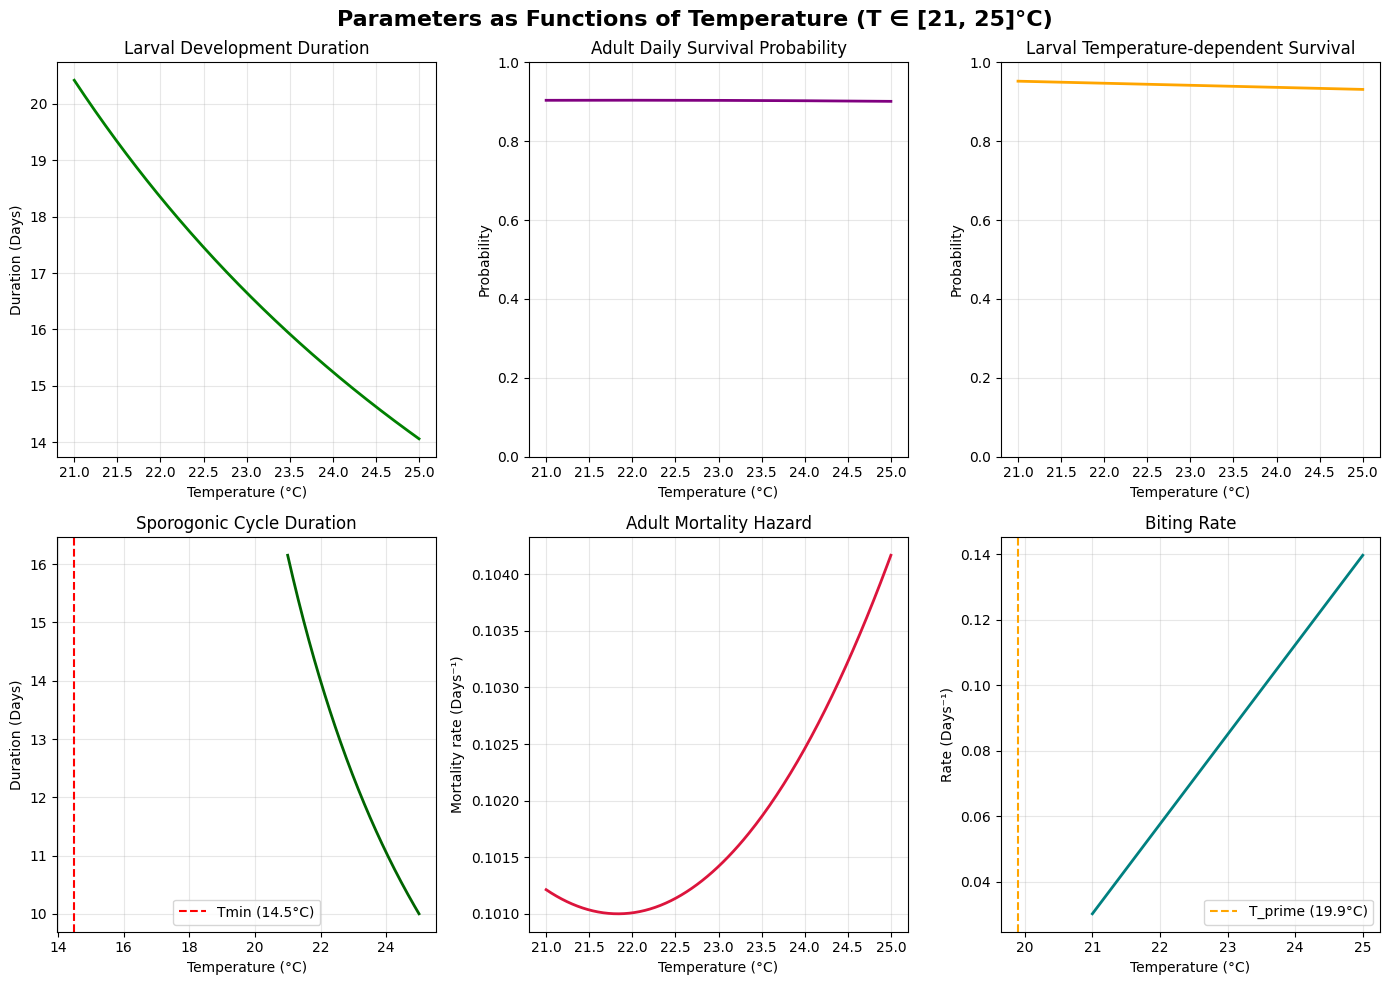

In [8]:
# ============================================================================
# FUNCTION OF TEMPERATURE PLOTS
# ============================================================================

temp_range = np.linspace(21, 25, 200)

fig2, axes2 = plt.subplots(2, 3, figsize=(14, 10))
fig2.suptitle('Parameters as Functions of Temperature (T ∈ [21, 25]°C)', fontsize=16, fontweight='bold')

# tau_L vs Temperature
tau_L_temp = np.array([tau_L(T) for T in temp_range])
axes2[0, 0].plot(temp_range, tau_L_temp, 'g-', linewidth=2)
axes2[0, 0].set_xlabel('Temperature (°C)')
axes2[0, 0].set_ylabel('Duration (Days)')
axes2[0, 0].set_title('Larval Development Duration')
axes2[0, 0].grid(True, alpha=0.3)

# p_T vs Temperature
p_T_temp = np.array([p_T(T) for T in temp_range])
axes2[0, 1].plot(temp_range, p_T_temp, 'purple', linewidth=2)
axes2[0, 1].set_xlabel('Temperature (°C)')
axes2[0, 1].set_ylabel('Probability')
axes2[0, 1].set_title('Adult Daily Survival Probability')
axes2[0, 1].grid(True, alpha=0.3)
axes2[0, 1].set_ylim([0, 1])

# p_LT vs Temperature
p_LT_temp = np.array([p_LT(T) for T in temp_range])
axes2[0, 2].plot(temp_range, p_LT_temp, 'orange', linewidth=2)
axes2[0, 2].set_xlabel('Temperature (°C)')
axes2[0, 2].set_ylabel('Probability')
axes2[0, 2].set_title('Larval Temperature-dependent Survival')
axes2[0, 2].grid(True, alpha=0.3)
axes2[0, 2].set_ylim([0, 1])

# tau_M vs Temperature
tau_M_temp = np.array([tau_M(T) for T in temp_range if T > Tmin])
tau_M_temp_x = temp_range[temp_range > Tmin]
axes2[1, 0].plot(tau_M_temp_x, tau_M_temp, 'darkgreen', linewidth=2)
axes2[1, 0].set_xlabel('Temperature (°C)')
axes2[1, 0].set_ylabel('Duration (Days)')
axes2[1, 0].set_title('Sporogonic Cycle Duration')
axes2[1, 0].grid(True, alpha=0.3)
axes2[1, 0].axvline(Tmin, color='red', linestyle='--', label=f'Tmin ({Tmin}°C)')
axes2[1, 0].legend()

# mu vs Temperature
mu_temp = np.array([mu(T) for T in temp_range if p_T(T) > 0])
mu_temp_x = temp_range[p_T(temp_range) > 0]
axes2[1, 1].plot(mu_temp_x, mu_temp, 'crimson', linewidth=2)
axes2[1, 1].set_xlabel('Temperature (°C)')
axes2[1, 1].set_ylabel('Mortality rate (Days⁻¹)')
axes2[1, 1].set_title('Adult Mortality Hazard')
axes2[1, 1].grid(True, alpha=0.3)

# a vs Temperature
a_temp = np.array([a(T) for T in temp_range])
axes2[1, 2].plot(temp_range, a_temp, 'teal', linewidth=2)
axes2[1, 2].set_xlabel('Temperature (°C)')
axes2[1, 2].set_ylabel('Rate (Days⁻¹)')
axes2[1, 2].set_title('Biting Rate')
axes2[1, 2].grid(True, alpha=0.3)
axes2[1, 2].axvline(T_prime, color='orange', linestyle='--', label=f'T_prime ({T_prime}°C)')
axes2[1, 2].legend()

plt.tight_layout()
plt.show()

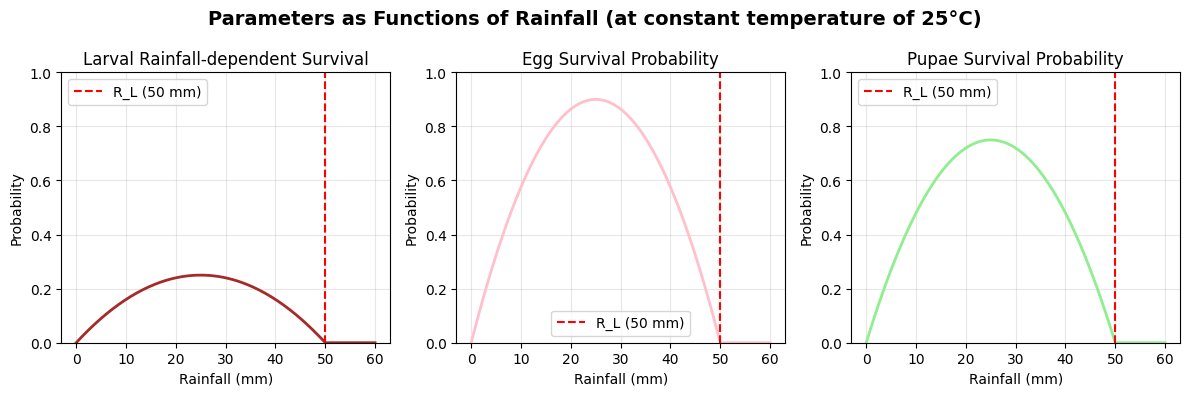

In [9]:
# ============================================================================
# FUNCTION OF RAINFALL PLOTS
# ============================================================================

rain_range = np.linspace(0, 60, 200)

fig3, axes3 = plt.subplots(1, 3, figsize=(12, 4))
fig3.suptitle('Parameters as Functions of Rainfall (at constant temperature of 25°C)', fontsize=14, fontweight='bold')

# p_LR vs Rainfall
p_LR_rain = np.array([p_LR(R) for R in rain_range])
axes3[0].plot(rain_range, p_LR_rain, 'brown', linewidth=2)
axes3[0].set_xlabel('Rainfall (mm)')
axes3[0].set_ylabel('Probability')
axes3[0].set_title('Larval Rainfall-dependent Survival')
axes3[0].grid(True, alpha=0.3)
axes3[0].axvline(R_L, color='red', linestyle='--', label=f'R_L ({R_L} mm)')
axes3[0].legend()
axes3[0].set_ylim([0, 1])

# p_ER vs Rainfall
p_ER_rain = np.array([p_ER(R) for R in rain_range])
axes3[1].plot(rain_range, p_ER_rain, 'pink', linewidth=2)
axes3[1].set_xlabel('Rainfall (mm)')
axes3[1].set_ylabel('Probability')
axes3[1].set_title('Egg Survival Probability')
axes3[1].grid(True, alpha=0.3)
axes3[1].axvline(R_L, color='red', linestyle='--', label=f'R_L ({R_L} mm)')
axes3[1].legend()
axes3[1].set_ylim([0, 1])

# p_PR vs Rainfall
p_PR_rain = np.array([p_PR(R) for R in rain_range])
axes3[2].plot(rain_range, p_PR_rain, 'lightgreen', linewidth=2)
axes3[2].set_xlabel('Rainfall (mm)')
axes3[2].set_ylabel('Probability')
axes3[2].set_title('Pupae Survival Probability')
axes3[2].grid(True, alpha=0.3)
axes3[2].axvline(R_L, color='red', linestyle='--', label=f'R_L ({R_L} mm)')
axes3[2].legend()
axes3[2].set_ylim([0, 1])

plt.tight_layout()
plt.show()

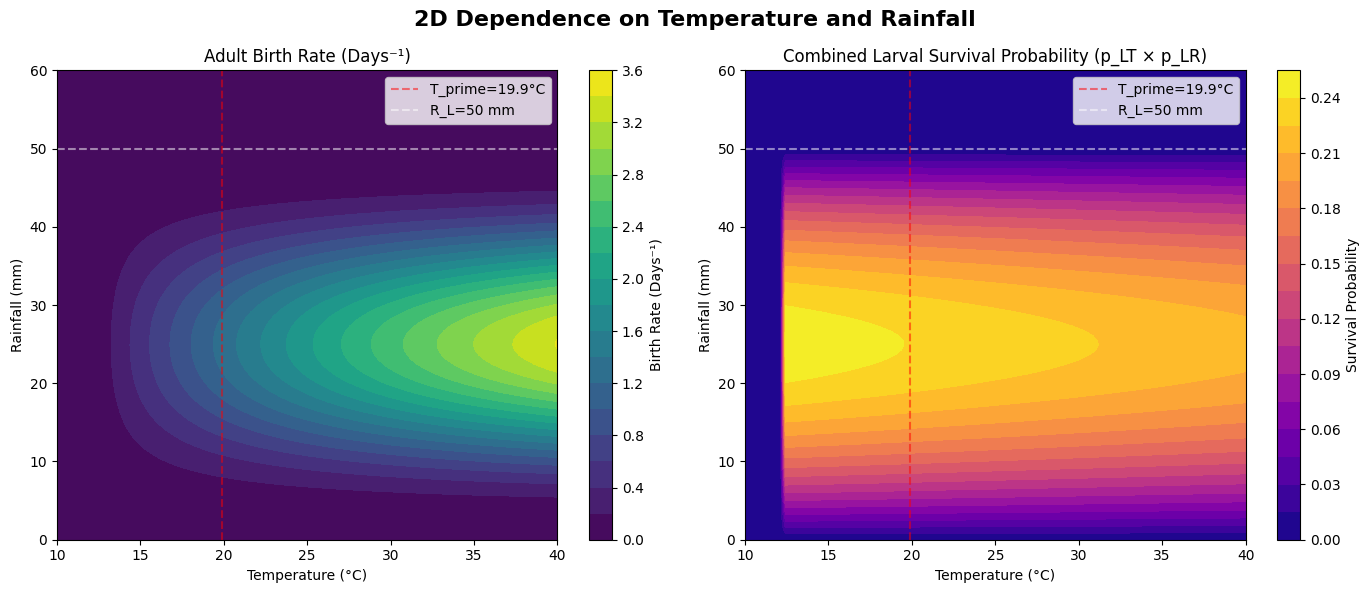

In [10]:
# ============================================================================
# 2D CONTOUR PLOTS - BIRTH RATE AND COMBINED LARVAL SURVIVAL
# ============================================================================

# Create meshgrid for temperature and rainfall
temp_grid = np.linspace(10, 40, 100)
rain_grid = np.linspace(0, 60, 100)
T_mesh, R_mesh = np.meshgrid(temp_grid, rain_grid)

# Calculate birth rate on the grid
birth_rate_grid = b(T_mesh, R_mesh)

# Calculate combined larval survival on the grid
larval_survival_grid = p_L_combined(T_mesh, R_mesh)

# Create figure with 2 subplots
fig_contour, axes_contour = plt.subplots(1, 2, figsize=(14, 6))
fig_contour.suptitle('2D Dependence on Temperature and Rainfall', fontsize=16, fontweight='bold')

# Contour plot for Birth Rate
contour1 = axes_contour[0].contourf(T_mesh, R_mesh, birth_rate_grid, levels=20, cmap='viridis')
axes_contour[0].set_xlabel('Temperature (°C)')
axes_contour[0].set_ylabel('Rainfall (mm)')
axes_contour[0].set_title('Adult Birth Rate (Days⁻¹)')
axes_contour[0].axvline(T_prime, color='red', linestyle='--', alpha=0.5, label=f'T_prime={T_prime}°C')
axes_contour[0].axhline(R_L, color='white', linestyle='--', alpha=0.5, label=f'R_L={R_L} mm')
axes_contour[0].legend()
plt.colorbar(contour1, ax=axes_contour[0], label='Birth Rate (Days⁻¹)')

# Contour plot for Combined Larval Survival
contour2 = axes_contour[1].contourf(T_mesh, R_mesh, larval_survival_grid, levels=20, cmap='plasma')
axes_contour[1].set_xlabel('Temperature (°C)')
axes_contour[1].set_ylabel('Rainfall (mm)')
axes_contour[1].set_title('Combined Larval Survival Probability (p_LT × p_LR)')
axes_contour[1].axvline(T_prime, color='red', linestyle='--', alpha=0.5, label=f'T_prime={T_prime}°C')
axes_contour[1].axhline(R_L, color='white', linestyle='--', alpha=0.5, label=f'R_L={R_L} mm')
axes_contour[1].legend()
plt.colorbar(contour2, ax=axes_contour[1], label='Survival Probability')

plt.tight_layout()
plt.show()

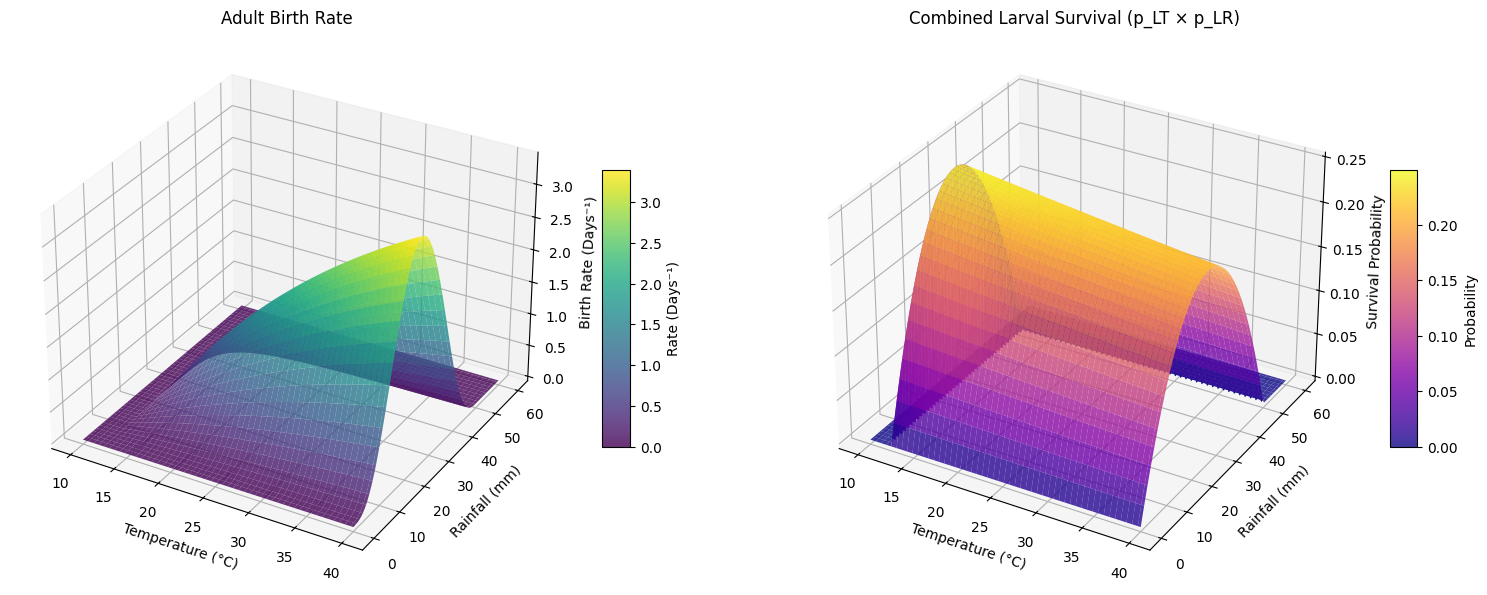

In [11]:
# ============================================================================
# 3D SURFACE PLOTS
# ============================================================================

fig_3d = plt.figure(figsize=(16, 6))

# 3D Surface plot for Birth Rate
ax1 = fig_3d.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(T_mesh, R_mesh, birth_rate_grid, cmap='viridis', alpha=0.8, linewidth=0, antialiased=True)
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Rainfall (mm)')
ax1.set_zlabel('Birth Rate (Days⁻¹)')
ax1.set_title('Adult Birth Rate')
fig_3d.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Rate (Days⁻¹)')

# 3D Surface plot for Combined Larval Survival
ax2 = fig_3d.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(T_mesh, R_mesh, larval_survival_grid, cmap='plasma', alpha=0.8, linewidth=0, antialiased=True)
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Rainfall (mm)')
ax2.set_zlabel('Survival Probability')
ax2.set_title('Combined Larval Survival (p_LT × p_LR)')
fig_3d.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='Probability')

plt.tight_layout()
plt.show()

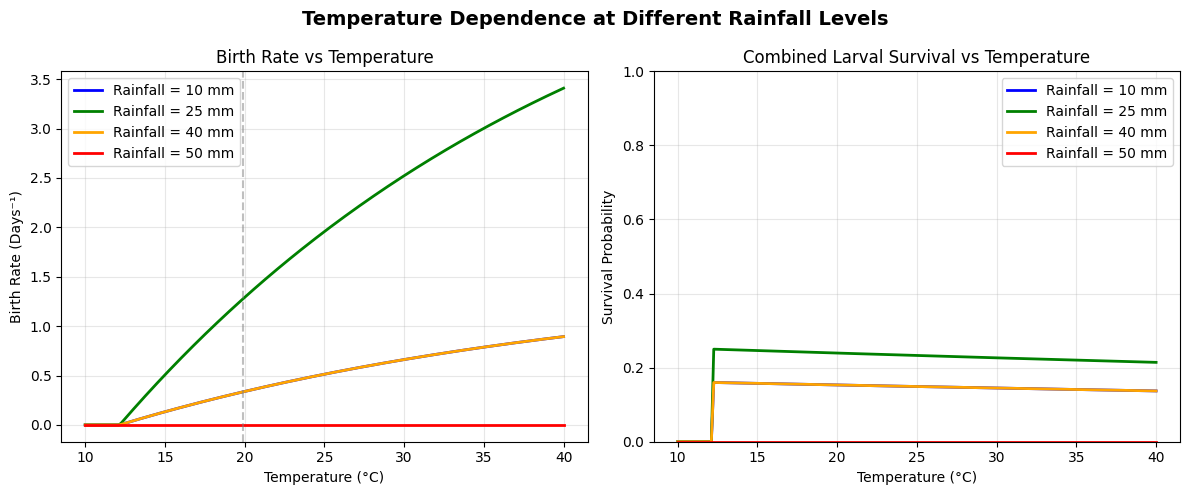

In [12]:
# ============================================================================
# FUNCTION OF TEMPERATURE PLOTS (with different rainfall levels for birth rate and combined survival)
# ============================================================================

temp_range = np.linspace(10, 40, 200)
rainfall_levels = [10, 25, 40, 50]  # Different rainfall levels to show

fig_temp, axes_temp = plt.subplots(1, 2, figsize=(12, 5))
fig_temp.suptitle('Temperature Dependence at Different Rainfall Levels', fontsize=14, fontweight='bold')

# Plot birth rate vs temperature for different rainfall levels
colors = ['blue', 'green', 'orange', 'red']
for i, rain_val in enumerate(rainfall_levels):
    birth_rate_temp = b(temp_range, rain_val)
    axes_temp[0].plot(temp_range, birth_rate_temp, color=colors[i], linewidth=2, 
                      label=f'Rainfall = {rain_val} mm')
axes_temp[0].set_xlabel('Temperature (°C)')
axes_temp[0].set_ylabel('Birth Rate (Days⁻¹)')
axes_temp[0].set_title('Birth Rate vs Temperature')
axes_temp[0].grid(True, alpha=0.3)
axes_temp[0].axvline(T_prime, color='gray', linestyle='--', alpha=0.5)
axes_temp[0].legend()

# Plot combined larval survival vs temperature for different rainfall levels
for i, rain_val in enumerate(rainfall_levels):
    larval_survival_temp = p_L_combined(temp_range, rain_val)
    axes_temp[1].plot(temp_range, larval_survival_temp, color=colors[i], linewidth=2, 
                      label=f'Rainfall = {rain_val} mm')
axes_temp[1].set_xlabel('Temperature (°C)')
axes_temp[1].set_ylabel('Survival Probability')
axes_temp[1].set_title('Combined Larval Survival vs Temperature')
axes_temp[1].grid(True, alpha=0.3)
axes_temp[1].legend()
axes_temp[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()


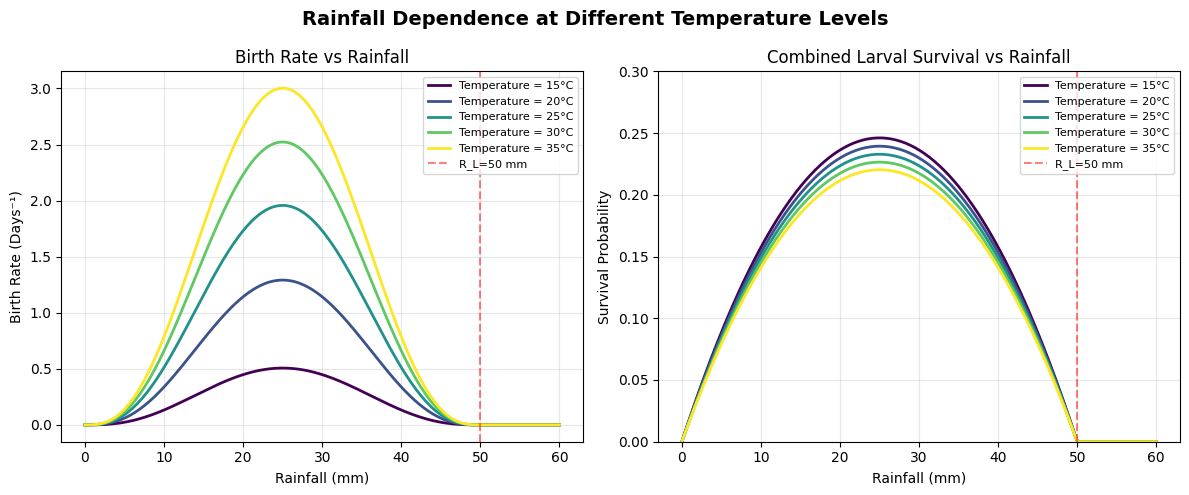

In [13]:
# ============================================================================
# FUNCTION OF RAINFALL PLOTS (with different temperature levels for birth rate and combined survival)
# ============================================================================

rain_range = np.linspace(0, 60, 200)
temperature_levels = [15, 20, 25, 30, 35]  # Different temperature levels to show

fig_rain, axes_rain = plt.subplots(1, 2, figsize=(12, 5))
fig_rain.suptitle('Rainfall Dependence at Different Temperature Levels', fontsize=14, fontweight='bold')

# Plot birth rate vs rainfall for different temperature levels
colors = plt.cm.viridis(np.linspace(0, 1, len(temperature_levels)))
for i, temp_val in enumerate(temperature_levels):
    birth_rate_rain = b(temp_val, rain_range)
    axes_rain[0].plot(rain_range, birth_rate_rain, color=colors[i], linewidth=2, 
                      label=f'Temperature = {temp_val}°C')
axes_rain[0].set_xlabel('Rainfall (mm)')
axes_rain[0].set_ylabel('Birth Rate (Days⁻¹)')
axes_rain[0].set_title('Birth Rate vs Rainfall')
axes_rain[0].grid(True, alpha=0.3)
axes_rain[0].axvline(R_L, color='red', linestyle='--', alpha=0.5, label=f'R_L={R_L} mm')
axes_rain[0].legend(loc='upper right', fontsize=8)

# Plot combined larval survival vs rainfall for different temperature levels
for i, temp_val in enumerate(temperature_levels):
    larval_survival_rain = p_L_combined(temp_val, rain_range)
    axes_rain[1].plot(rain_range, larval_survival_rain, color=colors[i], linewidth=2, 
                      label=f'Temperature = {temp_val}°C')
axes_rain[1].set_xlabel('Rainfall (mm)')
axes_rain[1].set_ylabel('Survival Probability')
axes_rain[1].set_title('Combined Larval Survival vs Rainfall')
axes_rain[1].grid(True, alpha=0.3)
axes_rain[1].axvline(R_L, color='red', linestyle='--', alpha=0.5, label=f'R_L={R_L} mm')
axes_rain[1].legend(loc='upper right', fontsize=8)
axes_rain[1].set_ylim([0, 0.3])

plt.tight_layout()
plt.show()